<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/3layer_nn_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1,1)

# Pick only 3 features
X = X[:, :3]

# Normalize
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

N = X.shape[0]

In [ ]:
input_dim = 3
h1, h2 = 32, 16
output_dim = 1

W1 = np.random.randn(input_dim, h1) * np.sqrt(2/input_dim)
b1 = np.zeros((1, h1))

W2 = np.random.randn(h1, h2) * np.sqrt(2/h1)
b2 = np.zeros((1, h2))

W3 = np.random.randn(h2, output_dim) * np.sqrt(2/h2)
b3 = np.zeros((1, output_dim))

lr = 0.01
epochs = 1000

In [ ]:
def relu(Z):
    return np.maximum(0, Z)

def relu_deriv(Z):
    return (Z > 0).astype(float)

In [ ]:
losses = []

for epoch in range(epochs):

    # Forward
    Z1 = tf.einsum('ij,jk->ik', X, W1).numpy() + b1
    A1 = relu(Z1)

    Z2 = tf.einsum('ij,jk->ik', A1, W2).numpy() + b2
    A2 = relu(Z2)

    Z3 = tf.einsum('ij,jk->ik', A2, W3).numpy() + b3
    y_pred = Z3

    # Loss
    loss = np.mean((y_pred - y)**2)
    losses.append(loss)

    # Backprop
    dZ3 = 2 * (y_pred - y) / N
    dW3 = tf.einsum('ij,ik->jk', A2, dZ3).numpy()
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = tf.einsum('ij,kj->ik', dZ3, W3).numpy()
    dZ2 = dA2 * relu_deriv(Z2)
    dW2 = tf.einsum('ij,ik->jk', A1, dZ2).numpy()
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = tf.einsum('ij,kj->ik', dZ2, W2).numpy()
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = tf.einsum('ij,ik->jk', X, dZ1).numpy()
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W3 -= lr * dW3
    b3 -= lr * db3

    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("Final Loss:", losses[-1])

Epoch 0, Loss: 2.5975
Epoch 200, Loss: 0.4551
Epoch 400, Loss: 0.4393
Epoch 600, Loss: 0.4335
Epoch 800, Loss: 0.4308
Final Loss: 0.42908598777949963


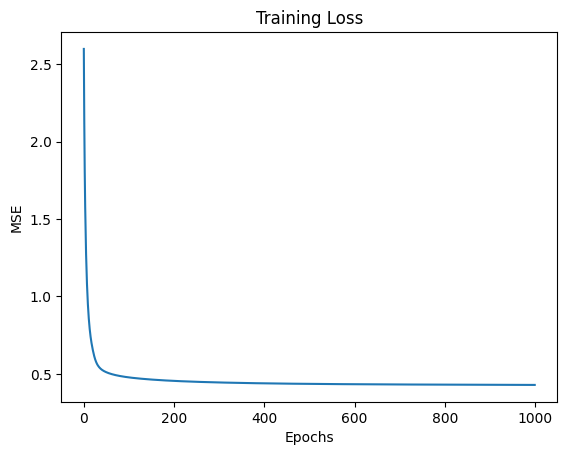

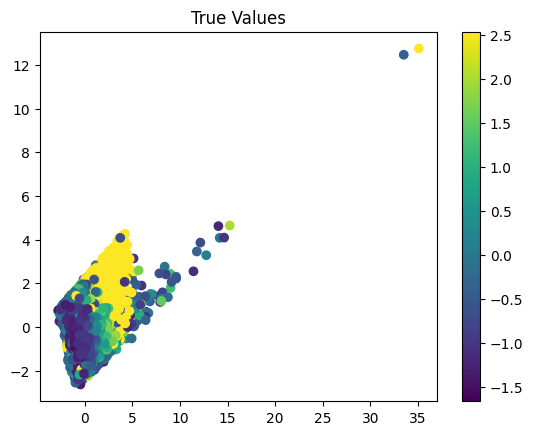

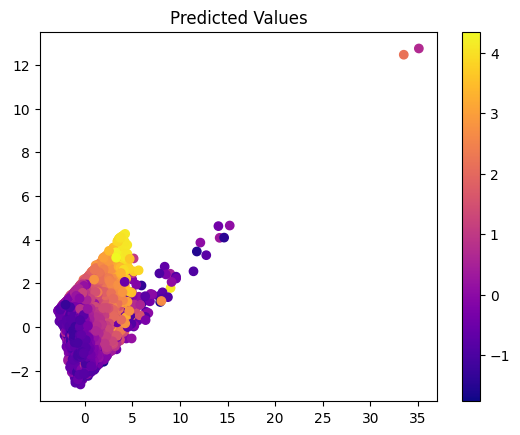

In [ ]:
# Predictions
Z1 = tf.einsum('ij,jk->ik', X, W1).numpy() + b1
A1 = relu(Z1)
Z2 = tf.einsum('ij,jk->ik', A1, W2).numpy() + b2
A2 = relu(Z2)
y_pred = tf.einsum('ij,jk->ik', A2, W3).numpy() + b3

# Loss curve
plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

# PCA for visualization
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

plt.figure()
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y.flatten(), cmap='viridis')
plt.title("True Values")
plt.colorbar()
plt.show()

plt.figure()
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y_pred.flatten(), cmap='plasma')
plt.title("Predicted Values")
plt.colorbar()
plt.show()